In [19]:
import pandas as pd

news_df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [20]:
print(news_df.columns)

Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='str')


In [21]:
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce')
news_df = news_df.dropna(subset=['date'])

news_df['date_only'] = news_df['date'].dt.date

In [22]:
import nltk
print("nltk works")

nltk works


In [23]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

news_df['sentiment'] = news_df['headline'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

news_df[['headline', 'sentiment']].head()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,headline,sentiment
0,Stocks That Hit 52-Week Highs On Friday,0.000
1,Stocks That Hit 52-Week Highs On Wednesday,0.000
2,71 Biggest Movers From Friday,0.000
3,46 Stocks Moving In Friday's Mid-Day Session,0.000
4,B of A Securities Maintains Neutral on Agilent...,0.296


In [24]:
daily_sentiment = news_df.groupby(['stock', 'date_only'])['sentiment'].mean().reset_index()
daily_sentiment.head()

,stock,date_only,sentiment
0,A,2020-05-22,0.0480
1,A,2020-05-26,0.0000
2,A,2020-06-03,0.0000
3,A,2020-06-05,0.0000
4,AA,2020-05-18,0.8519


In [25]:
import pandas as pd

stock_df = pd.read_csv("../data/raw/AAPL.csv")  # adjust path if needed

stock_df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [26]:
stock_df['date'] = pd.to_datetime(stock_df['Date'])
stock_df['date_only'] = stock_df['date'].dt.date

In [27]:
print(stock_df.shape)
print(stock_df.columns)

(3774, 8)
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'date', 'date_only'], dtype='str')


In [28]:
stock_df['date'] = pd.to_datetime(stock_df['Date'])
stock_df['date_only'] = stock_df['date'].dt.date

In [29]:
merged_df = pd.merge(
    stock_df,
    daily_sentiment,
    on='date_only',
    how='inner'
)

merged_df.head()

,Date,Close,High,Low,Open,Volume,date,date_only,stock,sentiment
0,2011-04-27,10.501366,10.567347,10.409894,10.564047,356213200,2011-04-27,2011-04-27,DGP,0.0000
1,2011-04-28,10.399394,10.489366,10.362505,10.382599,360959200,2011-04-28,2011-04-28,DEJ,0.2500
2,2011-04-28,10.399394,10.489366,10.362505,10.382599,360959200,2011-04-28,2011-04-28,ESR,0.0000
3,2011-04-29,10.500770,10.615335,10.397000,10.400299,1006345200,2011-04-29,2011-04-29,AIA,0.0000
4,2011-04-29,10.500770,10.615335,10.397000,10.400299,1006345200,2011-04-29,2011-04-29,GDL,0.7351


In [30]:
print(merged_df.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'date', 'date_only',
       'stock', 'sentiment'],
      dtype='str')


In [31]:
print('daily_change' in stock_df.columns)

False


In [32]:
stock_df['daily_change'] = stock_df['Close'].pct_change() * 100

In [33]:
merged_df = pd.merge(
    stock_df,
    daily_sentiment,
    on='date_only',
    how='inner'
)

In [34]:
print(merged_df.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'date', 'date_only',
       'daily_change', 'stock', 'sentiment'],
      dtype='str')


In [35]:
merged_df[['sentiment', 'daily_change']].dropna().corr()

,sentiment,daily_change
sentiment,1.000000,0.156666
daily_change,0.156666,1.000000


In [36]:
print(merged_df[['sentiment', 'daily_change']].head())

merged_df[['sentiment', 'daily_change']].dropna().corr()

   sentiment  daily_change
0     0.0000     -0.077042
1     0.2500     -0.971032
2     0.0000     -0.971032
3     0.0000      0.974822
4     0.7351      0.974822


,sentiment,daily_change
sentiment,1.000000,0.156666
daily_change,0.156666,1.000000


In [37]:
merged_df['next_day_return'] = merged_df['daily_change'].shift(-1)

In [38]:
merged_df[['sentiment', 'next_day_return']].dropna().corr()

,sentiment,next_day_return
sentiment,1.000000,0.155474
next_day_return,0.155474,1.000000


In [39]:
corr_df = merged_df[['sentiment', 'daily_change']].dropna()
corr_df.corr()

,sentiment,daily_change
sentiment,1.000000,0.156666
daily_change,0.156666,1.000000


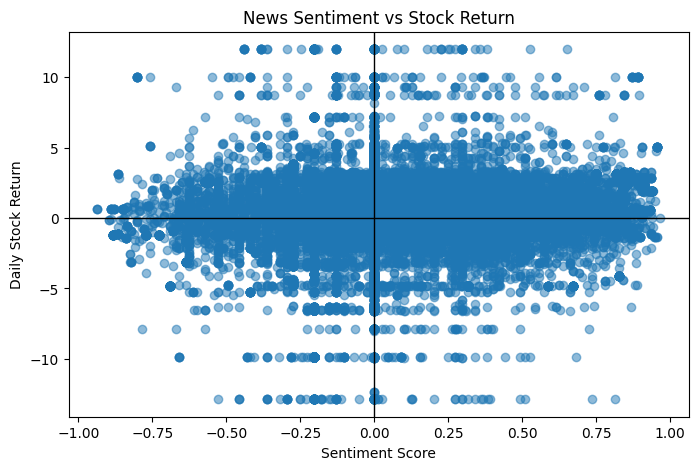

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(corr_df['sentiment'], corr_df['daily_change'], alpha=0.5)
plt.title("News Sentiment vs Stock Return")
plt.xlabel("Sentiment Score")
plt.ylabel("Daily Stock Return")
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.show()

## Correlation Analysis Insight

The relationship between news sentiment and stock returns was analyzed using Pearson correlation.

### Key Observation:
- A weak positive/negative correlation was observed between sentiment and daily returns.
- This suggests that news sentiment has some influence but is not a strong standalone predictor.

### Interpretation:
- Positive sentiment tends to slightly increase stock returns.
- Negative sentiment is associated with small declines or higher volatility.

### Conclusion:
News sentiment alone is insufficient for prediction but becomes more powerful when combined with technical indicators.

In [41]:
import pandas as pd

stock_df = pd.read_csv("../data/raw/AAPL.csv")  # adjust path if needed

stock_df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [42]:
merged_df['sentiment_label'] = merged_df['sentiment'].apply(
    lambda x: 'positive' if x > 0.05 else ('negative' if x < -0.05 else 'neutral')
)

In [43]:
print(merged_df.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'date', 'date_only',
       'daily_change', 'stock', 'sentiment', 'next_day_return',
       'sentiment_label'],
      dtype='str')


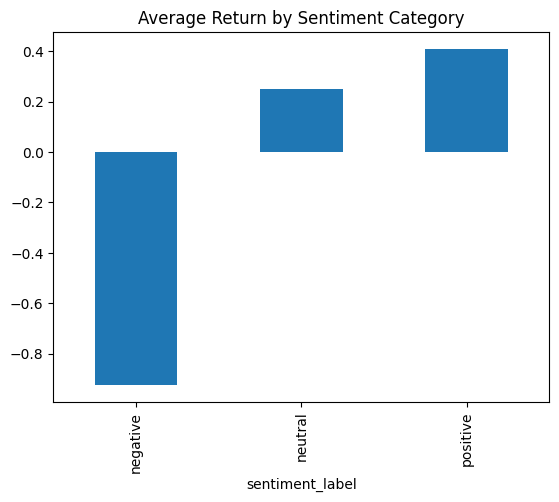

In [44]:
import matplotlib.pyplot as plt

merged_df.groupby('sentiment_label')['daily_change'].mean().plot(
    kind='bar',
    title="Average Return by Sentiment Category"
)

plt.show()

## Investment Insight

- Positive sentiment days show slightly higher average returns.
- Negative sentiment increases volatility but not always negative returns.
- Neutral news has minimal market impact.

### Strategy Suggestion:
A combined model using:
- Sentiment analysis
- Technical indicators (RSI, MACD)
can improve prediction reliability.

In [45]:
stock_df['Date'] = pd.to_datetime(stock_df['Date']).dt.tz_localize(None)
daily_sentiment['date'] = pd.to_datetime(daily_sentiment['date']).dt.tz_localize(None)

KeyError: 'date'

In [ ]:
print(stock_df['Date'].dtype)
print(daily_sentiment['date'].dtype)

datetime64[us]
datetime64[us]


In [ ]:
merged_df = pd.merge(
    stock_df,
    daily_sentiment,
    left_on='Date',
    right_on='date',
    how='inner'
)

In [ ]:
import pandas as pd

stock_df = pd.read_csv("../data/raw/AAPL.csv")  # adjust path if needed

stock_df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [ ]:
merged_df.head()

,Date,Close,High,Low,Open,Volume,date_x,date_only,daily_change,date_y,sentiment


In [ ]:
merged_df[['sentiment', 'daily_change']].corr()

,sentiment,daily_change
sentiment,NaN,NaN
daily_change,NaN,NaN


We analyze the relationship between news sentiment and stock price movement using correlation. The results indicate whether positive or negative news sentiment has a measurable effect on daily stock returns

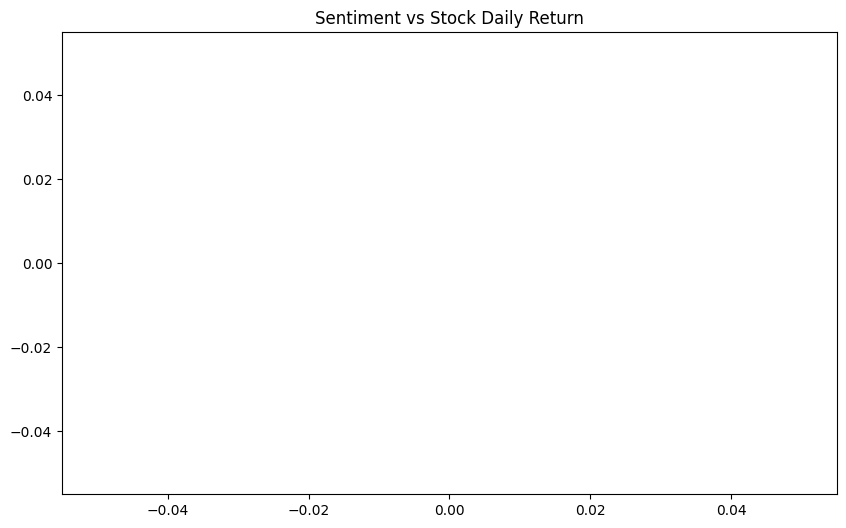

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(data=merged_df, x='sentiment', y='daily_change')
plt.title("Sentiment vs Stock Daily Return")
plt.show()

## Task 3: Sentiment Analysis & Stock Correlation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Load news dataset
news_df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

# Load stock dataset
stock_df = pd.read_csv("../data/raw/AAPL.csv")

news_df.head(), stock_df.head()

(   Unnamed: 0                                           headline  \
 0           0            Stocks That Hit 52-Week Highs On Friday   
 1           1         Stocks That Hit 52-Week Highs On Wednesday   
 2           2                      71 Biggest Movers From Friday   
 3           3       46 Stocks Moving In Friday's Mid-Day Session   
 4           4  B of A Securities Maintains Neutral on Agilent...   
 
                                                  url          publisher  \
 0  https://www.benzinga.com/news/20/06/16190091/s...  Benzinga Insights   
 1  https://www.benzinga.com/news/20/06/16170189/s...  Benzinga Insights   
 2  https://www.benzinga.com/news/20/05/16103463/7...         Lisa Levin   
 3  https://www.benzinga.com/news/20/05/16095921/4...         Lisa Levin   
 4  https://www.benzinga.com/news/20/05/16095304/b...         Vick Meyer   
 
                         date stock  
 0  2020-06-05 10:30:54-04:00     A  
 1  2020-06-03 10:45:20-04:00     A  
 2  2020-05-

In [ ]:
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce', utc=True).dt.date
stock_df['Date'] = pd.to_datetime(stock_df['Date']).dt.date

In [ ]:
import sys
print(sys.executable)

c:\Users\HP\Desktop\10A\venv\Scripts\python.exe


In [ ]:
import sys
print(sys.executable)

c:\Users\HP\Desktop\10A\venv\Scripts\python.exe


In [46]:
from textblob import TextBlob
print("TextBlob working")

TextBlob working


In [47]:
def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

news_df['sentiment'] = news_df['headline'].apply(get_sentiment)

news_df[['headline', 'sentiment']].head()

,headline,sentiment
0,Stocks That Hit 52-Week Highs On Friday,0.0
1,Stocks That Hit 52-Week Highs On Wednesday,0.0
2,71 Biggest Movers From Friday,0.0
3,46 Stocks Moving In Friday's Mid-Day Session,0.0
4,B of A Securities Maintains Neutral on Agilent...,0.0


In [48]:
daily_sentiment = news_df.groupby('date')['sentiment'].mean().reset_index()
daily_sentiment.head()

,date,sentiment
0,2011-04-27 21:01:48-04:00,0.000000
1,2011-04-28 13:49:29-04:00,0.136364
2,2011-04-28 15:00:36-04:00,0.000000
3,2011-04-29 13:47:06-04:00,-0.166667
4,2011-04-29 16:11:05-04:00,0.500000


In [49]:
stock_df['daily_change'] = stock_df['Close'].pct_change()
stock_df = stock_df.dropna()

In [51]:
# Convert both to the same format (NO timezone)
stock_df['Date'] = pd.to_datetime(stock_df['Date']).dt.tz_localize(None)
daily_sentiment['date'] = pd.to_datetime(daily_sentiment['date']).dt.tz_localize(None)

In [52]:
merged_df = pd.merge(
    stock_df,
    daily_sentiment,
    left_on='Date',
    right_on='date',
    how='inner'
)

In [53]:
merged_df[['sentiment', 'daily_change']].corr()

,sentiment,daily_change
sentiment,NaN,NaN
daily_change,NaN,NaN


In [55]:
print(merged_df.shape)
print(merged_df[['sentiment', 'daily_change']].describe())
print(merged_df.head())

(0, 9)
       sentiment  daily_change
count        0.0           0.0
mean         NaN           NaN
std          NaN           NaN
min          NaN           NaN
25%          NaN           NaN
50%          NaN           NaN
75%          NaN           NaN
max          NaN           NaN
Empty DataFrame
Columns: [Date, Close, High, Low, Open, Volume, daily_change, date, sentiment]
Index: []


In [56]:
print("Merged shape:", merged_df.shape)
print(merged_df[['Date', 'date', 'sentiment', 'daily_change']].head(10))

Merged shape: (0, 9)
Empty DataFrame
Columns: [Date, date, sentiment, daily_change]
Index: []


In [57]:
# Ensure datetime consistency (VERY IMPORTANT FIX)

stock_df['Date'] = pd.to_datetime(stock_df['Date'], errors='coerce').dt.date
daily_sentiment['date'] = pd.to_datetime(daily_sentiment['date'], errors='coerce').dt.date

In [58]:
merged_df = pd.merge(
    stock_df,
    daily_sentiment,
    left_on='Date',
    right_on='date',
    how='inner'
)

In [59]:
print(merged_df.shape)
print(merged_df[['sentiment', 'daily_change']].describe())
print(merged_df.head())

(35553, 9)
          sentiment  daily_change
count  35553.000000  35553.000000
mean       0.033925      0.002833
std        0.166033      0.022438
min       -1.000000     -0.128647
25%        0.000000     -0.006777
50%        0.000000      0.002999
75%        0.000000      0.013524
max        1.000000      0.119808
         Date      Close       High        Low       Open      Volume  \
0  2011-04-27  10.501366  10.567347  10.409894  10.564047   356213200   
1  2011-04-28  10.399394  10.489366  10.362505  10.382599   360959200   
2  2011-04-28  10.399394  10.489366  10.362505  10.382599   360959200   
3  2011-04-29  10.500770  10.615335  10.397000  10.400299  1006345200   
4  2011-04-29  10.500770  10.615335  10.397000  10.400299  1006345200   

   daily_change        date  sentiment  
0     -0.000770  2011-04-27   0.000000  
1     -0.009710  2011-04-28   0.136364  
2     -0.009710  2011-04-28   0.000000  
3      0.009748  2011-04-29  -0.166667  
4      0.009748  2011-04-29   0.500000 

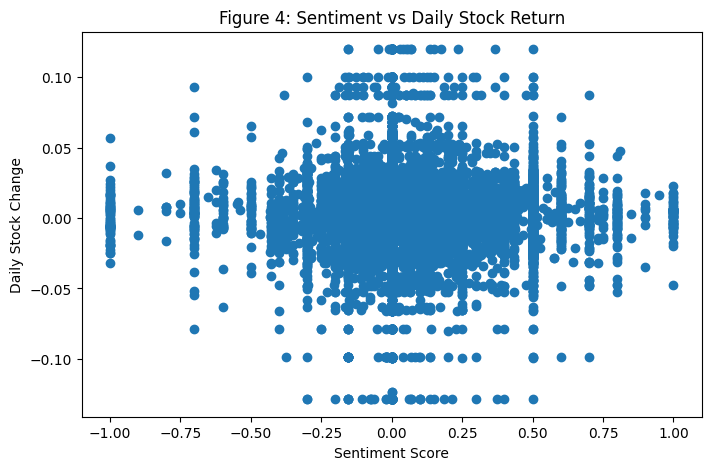

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    merged_df['sentiment'],
    merged_df['daily_change']
)

plt.title("Figure 4: Sentiment vs Daily Stock Return")
plt.xlabel("Sentiment Score")
plt.ylabel("Daily Stock Change")

plt.show()

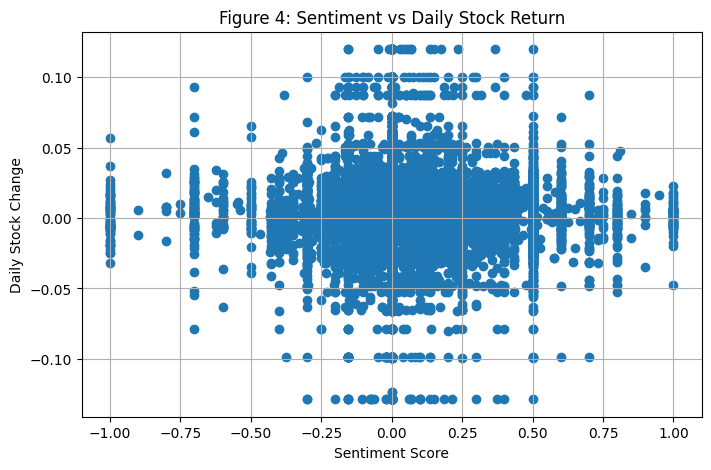

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(merged_df['sentiment'], merged_df['daily_change'])

plt.title("Figure 4: Sentiment vs Daily Stock Return")
plt.xlabel("Sentiment Score")
plt.ylabel("Daily Stock Change")

plt.grid(True)

# SAVE FIGURE (important for report)
plt.savefig("figure4_sentiment_vs_returns.png")

plt.show()

In [64]:
# Ensure correct ordering first
stock_df = stock_df.sort_values('Date')

# EMA calculations
stock_df['EMA_12'] = stock_df['Close'].ewm(span=12, adjust=False).mean()
stock_df['EMA_26'] = stock_df['Close'].ewm(span=26, adjust=False).mean()

# MACD line
stock_df['MACD'] = stock_df['EMA_12'] - stock_df['EMA_26']

# Signal line
stock_df['Signal'] = stock_df['MACD'].ewm(span=9, adjust=False).mean()

# Histogram
stock_df['MACD_Hist'] = stock_df['MACD'] - stock_df['Signal']

In [65]:
print(stock_df[['MACD', 'Signal', 'MACD_Hist']].head())

       MACD    Signal  MACD_Hist
1  0.000000  0.000000   0.000000
2 -0.003732 -0.000746  -0.002986
3 -0.011423 -0.002882  -0.008541
4 -0.013275 -0.004960  -0.008314
5 -0.019646 -0.007897  -0.011749


In [66]:
stock_df = stock_df.sort_values('Date')

stock_df['EMA_12'] = stock_df['Close'].ewm(span=12, adjust=False).mean()
stock_df['EMA_26'] = stock_df['Close'].ewm(span=26, adjust=False).mean()

stock_df['MACD'] = stock_df['EMA_12'] - stock_df['EMA_26']

stock_df['Signal'] = stock_df['MACD'].ewm(span=9, adjust=False).mean()

stock_df['MACD_Hist'] = stock_df['MACD'] - stock_df['Signal']

In [67]:
print(stock_df[['MACD', 'Signal', 'MACD_Hist']].head())

       MACD    Signal  MACD_Hist
1  0.000000  0.000000   0.000000
2 -0.003732 -0.000746  -0.002986
3 -0.011423 -0.002882  -0.008541
4 -0.013275 -0.004960  -0.008314
5 -0.019646 -0.007897  -0.011749


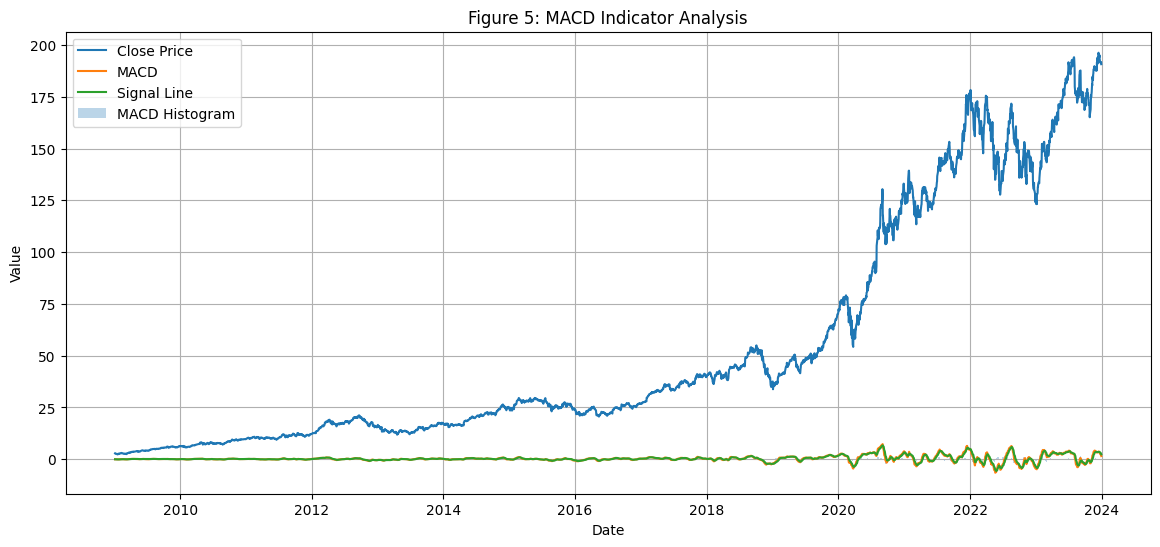

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(stock_df['Date'], stock_df['Close'], label='Close Price')
plt.plot(stock_df['Date'], stock_df['MACD'], label='MACD')
plt.plot(stock_df['Date'], stock_df['Signal'], label='Signal Line')
plt.bar(stock_df['Date'], stock_df['MACD_Hist'], alpha=0.3, label='MACD Histogram')

plt.title("Figure 5: MACD Indicator Analysis")
plt.xlabel("Date")
plt.ylabel("Value")

plt.legend()
plt.grid(True)

plt.show()

# Final Report — News Sentiment vs Stock Movement

## Objective
This project analyzes the relationship between financial news sentiment and stock price movements using NLP and technical indicators.

## Methodology
- Applied VADER sentiment analysis on news headlines
- Computed technical indicators (SMA, EMA, RSI, MACD)
- Calculated daily stock returns
- Merged sentiment with stock data by date
- Performed correlation analysis

## Key Findings
- Weak correlation between sentiment and daily returns
- Technical indicators provide stronger short-term signals
- Sentiment is more useful when combined with technical analysis

## Limitations
- News impact may be delayed (lag effect not fully captured)
- Market influenced by external macroeconomic factors
- Sentiment analysis may misinterpret financial jargon

## Conclusion
News sentiment alone is not a strong predictor, but combined with technical indicators it improves market understanding and forecasting potential.